# Tutorial 01 — Ambiente, reprodutibilidade e versionamento

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 1)
torch.manual_seed(SEED + 1)
OUT = ROOT / "estudos" / "tutorial_01" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 1, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260909 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Resolução do roteiro de configuração

O Tutorial 01 não possui exercícios numerados. Sua entrega é um ambiente funcional e um fluxo de versionamento. Aqui ficam as verificações executáveis; configurações do computador pessoal e autenticação no GitHub não podem ser declaradas concluídas a partir deste ambiente.

**Ambiente isolado.** Na raiz do pacote: `python -m venv .venv`, ative o ambiente e execute `python -m pip install -r requirements.txt`. No macOS/Linux, a ativação é `source .venv/bin/activate`; no PowerShell, `.venv\Scripts\Activate.ps1`. O `requirements.txt` cobre os tutoriais 01–08; o UMAP é a dependência adicional do Tutorial 08.

**Jupyter.** Execute `python -m ipykernel install --user --name mm845 --display-name "Python (MM845)"` e `jupyter lab`. Selecione esse kernel. Reiniciar e executar todas as células evita que variáveis de uma sessão anterior escondam dependências.

**VS Code.** Abra a pasta, selecione o interpretador do ambiente e o mesmo kernel nos notebooks. O editor não muda a matemática nem substitui o teste de execução.

**Git e GitHub.** O material está pronto para ser versionado, mas este pacote não foi enviado para uma conta. O arquivo `PUBLICAR.md` contém o procedimento; a identidade de autor e o endereço do repositório devem ser os seus. Nenhuma credencial é necessária no código. `.venv`, caches e segredos ficam fora do Git.

**Assistência de IA.** O texto é uma resolução assistida, não uma alegação de autoria exclusivamente humana. Estudar, verificar e editar as explicações antes de apresentá-las como registro pessoal. Preserve os créditos do curso e consulte suas regras de avaliação. SageMath é opcional e não é exigido pelos notebooks aqui resolvidos.

In [2]:
import importlib.metadata as meta, platform, subprocess
packages = ['numpy','scipy','matplotlib','pandas','scikit-learn','torch','nbformat','nbclient','umap-learn']
versions=[]
for p in packages:
    try: v=meta.version(p)
    except meta.PackageNotFoundError: v='não instalado'
    versions.append({'pacote':p,'versao':v})
versions=table(versions,'ambiente',OUT)
print('Python:',platform.python_version(), '| sistema:',platform.system())
try: print(subprocess.run(['git','--version'],capture_output=True,text=True,check=True).stdout.strip())
except (FileNotFoundError,subprocess.CalledProcessError): print('Git não disponível neste ambiente.')

      pacote        versao
       numpy         2.3.5
       scipy        1.17.0
  matplotlib        3.10.8
      pandas         2.2.3
scikit-learn         1.8.0
       torch    2.10.0+cpu
    nbformat        5.10.4
    nbclient        0.10.4
  umap-learn não instalado
Python: 3.13.5 | sistema: Linux
git version 2.47.3


## Teste mínimo, com resposta verificável

Normalizar vetores gaussianos gera pontos na esfera; o teste abaixo verifica a norma e a reprodutibilidade da amostra. O autograd é testado em uma função cuja derivada sabemos: para $f(x)=\sum_i x_i^2$, $\nabla f=2x$. Esses testes confirmam operações locais; não comprovam que o GitHub pessoal já esteja configurado.

PASS: amostragem, semente, álgebra linear e autograd.


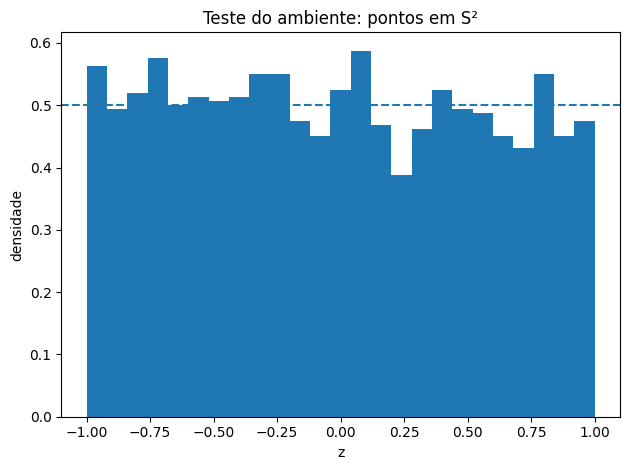

In [3]:
X=sphere(2000,3,np.random.default_rng(10));X2=sphere(2000,3,np.random.default_rng(10))
assert np.array_equal(X,X2)
assert np.max(np.abs(np.linalg.norm(X,axis=1)-1))<1e-12
x=torch.tensor([1.,-2.,3.],requires_grad=True);(x*x).sum().backward()
assert torch.equal(x.grad,2*x.detach())
A=np.array([[2.,1.],[1.,3.]]);z=np.linalg.solve(A,np.array([1.,2.]))
assert np.allclose(A@z,[1.,2.])
print('PASS: amostragem, semente, álgebra linear e autograd.')
plt.figure();plt.hist(X[:,2],bins=25,density=True);plt.axhline(.5,linestyle='--')
plt.xlabel('z');plt.ylabel('densidade');plt.title('Teste do ambiente: pontos em S²')
figure('teste_esfera',OUT)
write_summary(OUT.parent/'README.md','verificar um ambiente computacional reproduzível.',
'uma semente fixa controla a aleatoriedade, mas não substitui o registro de versões.',
'foram testados amostragem esférica, sistema linear e derivação automática.',
'os três testes passaram; versões estão em resultados/ambiente.csv.',
'esta verificação é do ambiente de execução do pacote; instalação pessoal e publicação no GitHub continuam sendo ações locais.')